This notebook serves as the main pipeline for the Python-based backtesting framework. It integrates the core modules of the project, including data preparation, feature engineering, model construction, model training and validation, portfolio construction, and out-of-sample backtesting.

The workflow is designed to call the underlying Python scripts as reusable modules rather than redefining all functions directly inside the notebook. This keeps the main logic modular and organized, while allowing the notebook to act as a clear execution and experiment interface.

Specifically, this pipeline loads the prepared market and stock-level data, computes the required features and market signals, constructs the uWN, cWN, and LSTM models, runs walk-forward training and validation, generates out-of-sample predictions, builds long-short and long-only portfolios, evaluates performance metrics, and saves the final results and plots for further analysis.

The purpose of this notebook is to provide a centralized and reproducible entry point for running the full modeling and backtesting process.

**0.** Project Structure Overview

This project is organized as a modular Python-based research and backtesting framework. The main components are separated into different folders according to their functions, including data processing, feature engineering, model implementation, backtesting, and result storage.

All the files should be formed as below modular python framework.

```text
IEOR4733-Final-Project/
├── data/
│   ├── raw/
│   │   ├── ohlcv.parquet             # Raw stock-level OHLCV data
│   │   ├── signals.parquet           # Raw market signal data
│   │   └── sp500_tickers.csv         # S&P 500 ticker universe
│   │
│   ├── processed/
│   │   └── features.parquet          # Processed feature dataset
│   │
│   ├── data_pipeline.py              # Data loading, cleaning, processing, and saving
│   └── features.py                   # Feature engineering for stock-level and market-level features
│
├── model/
│   ├── uWNcWN.py                     # Earlier implementation of uWN and cWN models
│   ├── uWNcWN2.py                    # Main model architecture for uWN and cWN
│   ├── lorenz_test2.py               # Lorenz test and model validation
│   ├── backtest.py                   # Earlier or additional backtesting script
│   └── backtest_uWNcWN_LSTM2.py      # Training, validation, prediction, portfolio construction, and backtesting
│
├── results/
│   ├── lorenz_test/                  # Outputs from the Lorenz test
│   └── uWNcWN_LSTM2/                 # Backtesting outputs, metrics, predictions, returns, and plots
│
├── Main_Pipeline.ipynb               # Main notebook pipeline that coordinates all Python modules
├── README.md                         # Project documentation
├── .gitignore                        # Git ignore configuration
└── .gitattributes                    # Git attributes configuration
```

The `./data/` folder contains the data-related modules and datasets. The raw market data is stored in `./data/raw/`, while processed datasets can be stored in `./data/processed/`. The script `./data/data_pipeline.py` is used to prepare the raw data, and `./data/features.py` contains the feature engineering functions for generating stock-level features and market-level signals.

The `./model/` folder contains the core model and evaluation scripts. The files `./model/uWNcWN.py` and `./model/uWNcWN2.py` define the unconditional WaveNet and conditional WaveNet model structures. The backtesting logic is implemented in `./model/backtest.py` and `./model/backtest_uWNcWN_LSTM2.py`, while `./model/lorenz_test2.py` is used for additional model evaluation through the Lorenz test.

The `./results/` folder is used to store the outputs generated by the pipeline, including lorenz test results, backtest results and sensitive analysis.

This notebook serves as the main execution pipeline of the project. Instead of rewriting all functions inside the notebook, it imports the existing Python modules and coordinates the full workflow from data preparation to model testing and backtesting.

**1.** Data preparation

In this section, we prepare the data required for model training, validation, and backtesting. Since the project is organized into separate `./data/` and `./model/` folders, we first update the Python search path so that the notebook can import the corresponding modules directly.

The data preparation process is mainly implemented in `./data/data_pipeline.py`. This module is responsible for loading the raw market data, cleaning and restructuring the dataset, and saving the processed files that will be used in the later modeling pipeline.

We also import `./data/features.py`, which contains the feature engineering functions. These functions are used to construct stock-level features and market-level signals, which serve as the input variables for the uWN, cWN, and LSTM models.

After importing the required modules, we run `data_pipeline.run_pipeline()` to execute the full data preparation process. This step ensures that the raw data is transformed into the required format before entering the model construction, validation, and backtesting stages.


In [3]:
import sys
import importlib

sys.path.append("./model")
sys.path.append("./data")

from data import features
from data import data_pipeline


In [4]:
data_pipeline.run_pipeline()


  Phase 1 - S&P 500 Data Pipeline (extended features)

╔══════════════════════════════════════════════════════╗
║          Feature Library Summary                     ║
╠══════════════════════════════════════════════════════╣
║  A Returns Momentum               9 features  ║
║  B Trend                          8 features  ║
║  C Volatility                     5 features  ║
║  D Oscillators                    7 features  ║
║  E Volume Liquidity               6 features  ║
║  F Price Structure                5 features  ║
║  G Market Signals                 8 features  ║
╠══════════════════════════════════════════════════════╣
║  Total (per-stock)               40 features  ║
║  Total (incl. market signals)    48 features  ║
╚══════════════════════════════════════════════════════╝

Step 1: Tickers
  [cache] Tickers loaded from disk.

Step 2: OHLCV
  [cache] OHLCV loaded from disk.

Step 3: Market signals
  [cache] Signals loaded from disk.

Step 4: Stock features
  Computing features fo

# 2. Reproduce the Model

In this part, we implement the unconditional WaveNet model, uWN, and the conditional WaveNet model, cWN, following the structure described in the paper. The corresponding model code is stored in `./model/uWNcWN2.py`.

Following the paper, we also conduct the Lorenz test to evaluate the model. The implementation of this test is stored in `./model/lorenz_test2.py`.

Here, we import the required model and testing modules, reload them to make sure the latest code is used, and then present the results of the Lorenz test.

In [5]:
from model import uWNcWN2
from model import lorenz_test2

importlib.reload(uWNcWN2)
importlib.reload(lorenz_test2)

<module 'model.lorenz_test2' from 'd:\\Columbia\\AlgoTrading\\FinalProject\\IEOR4733-Final-Project\\model\\lorenz_test2.py'>

Using device: cuda
Figure save directory: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test

Running experiment for X...
X: RMSE uWN (std) = 0.018441, RMSE cWN (std) = 0.014334, RMSE uWN (orig) = 0.127202, RMSE cWN (orig) = 0.098871


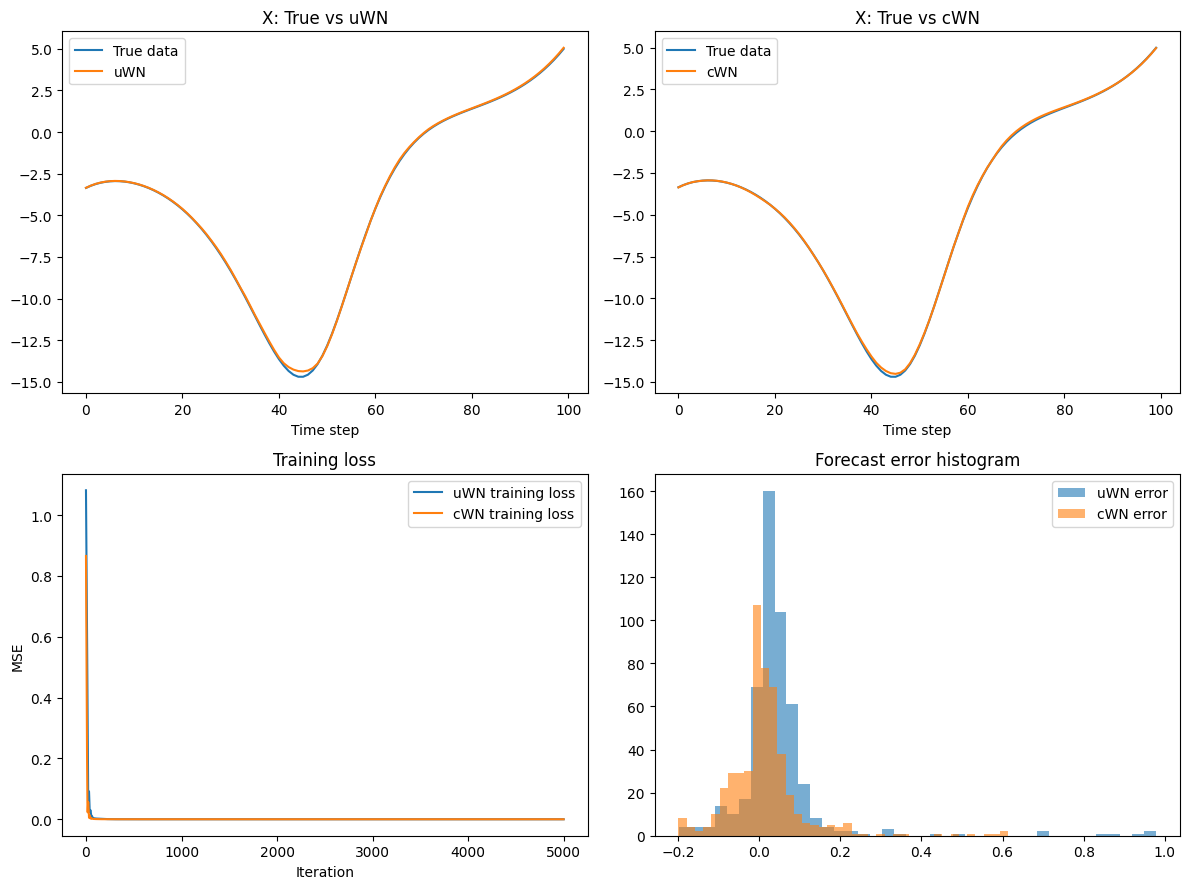

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_X.png

Running experiment for Y...
Y: RMSE uWN (std) = 0.022610, RMSE cWN (std) = 0.032951, RMSE uWN (orig) = 0.184382, RMSE cWN (orig) = 0.268704


<Figure size 640x480 with 0 Axes>

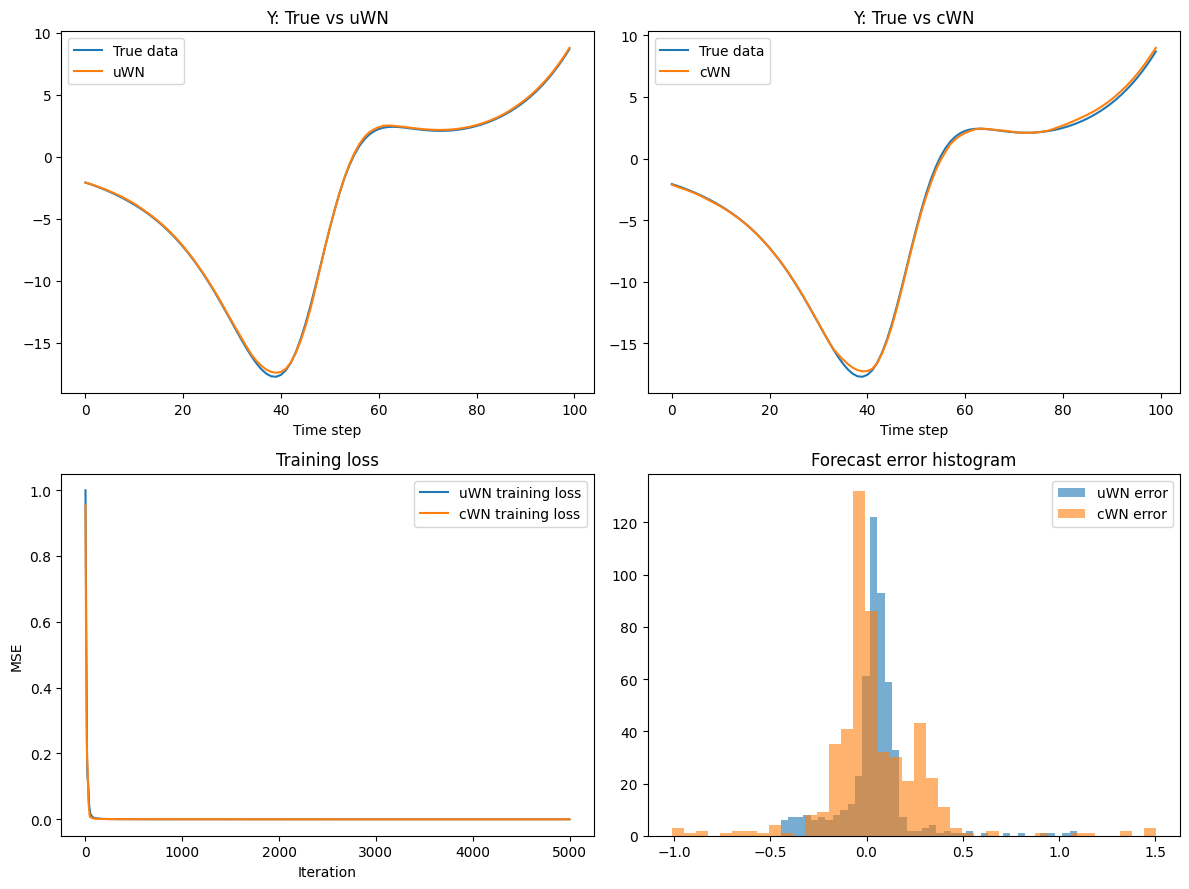

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_Y.png

Running experiment for Z...
Z: RMSE uWN (std) = 0.006412, RMSE cWN (std) = 0.030777, RMSE uWN (orig) = 0.059576, RMSE cWN (orig) = 0.285978


<Figure size 640x480 with 0 Axes>

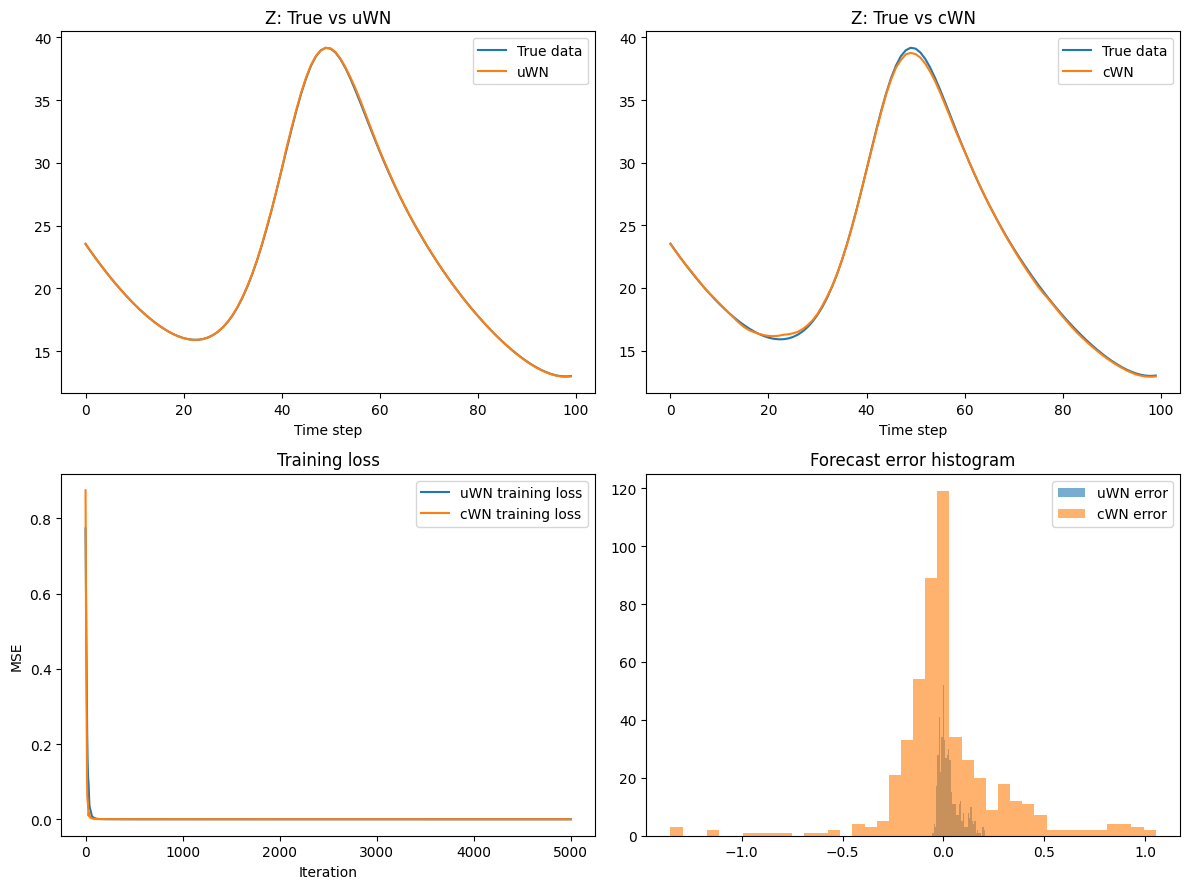

Saved figure: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\lorenz_Z.png

Saved RMSE summary to: d:\Columbia\AlgoTrading\FinalProject\IEOR4733-Final-Project\results\lorenz_test\rmse_summary.csv

===== RMSE Summary =====
Coordinate  RMSE_uWN_std  RMSE_cWN_std  RMSE_uWN_orig  RMSE_cWN_orig
         X      0.018441      0.014334       0.127202       0.098871
         Y      0.022610      0.032951       0.184382       0.268704
         Z      0.006412      0.030777       0.059576       0.285978


<Figure size 640x480 with 0 Axes>

In [6]:
lorenz_test2.lorenz_test()

The Lorenz test results provide an additional validation of the reproduced uWN and cWN model structures. The table reports the RMSE values for three coordinates, `x`, `y`, and `z`, under both the standardized setting and the original scale.

Overall, the RMSE values remain relatively small, especially for the standardized outputs. For the `x` coordinate, cWN achieves a lower standardized RMSE than uWN, with values of 0.014334 and 0.018441 respectively. This indicates that the conditional WaveNet is able to improve the fitting accuracy when market condition information is incorporated. For the original-scale results, cWN also improves upon uWN for the `x` coordinate, reducing the RMSE from 0.127202 to 0.098871.

Although cWN does not dominate uWN for every coordinate, the results are generally consistent with the expected behavior discussed in the paper. The conditional model can capture additional information through the conditioning variables, while the unconditional model still provides a stable benchmark. The Lorenz test therefore confirms that the reproduced model is able to generate reasonable and comparable outputs.

Based on these results, the model implementation is considered successful. The uWN and cWN structures have been correctly constructed and can be further integrated into the full training, validation, portfolio construction, and backtesting pipeline.

**3.** Backtesting Pipeline

In this section, we run the main backtesting pipeline for the uWN, cWN, and LSTM models. The corresponding implementation is provided in `./model/backtest_uWNcWN_LSTM2.py`.

This module integrates the major components of the empirical experiment, including feature loading, sample construction, rolling-window training, validation, prediction generation, portfolio construction, performance evaluation, and result visualization. The notebook imports and reloads the backtesting module to ensure that the latest version of the Python script is used.

The backtest is executed by calling `backtest_uWNcWN_LSTM2.backtest()`. The argument `--results_dir` is specified so that all generated outputs are saved into `./results/uWNcWN_LSTM2/`. These outputs include performance metrics, daily returns, cumulative returns, model predictions, and backtest plots.

This section serves as the final execution stage of the pipeline. After the data has been prepared and the model structures have been reproduced and validated, the backtesting module evaluates the out-of-sample performance of the models and compares their portfolio-level results.

In [7]:
from model import backtest_uWNcWN_LSTM2

importlib.reload(backtest_uWNcWN_LSTM2)

<module 'model.backtest_uWNcWN_LSTM2' from 'd:\\Columbia\\AlgoTrading\\FinalProject\\IEOR4733-Final-Project\\model\\backtest_uWNcWN_LSTM2.py'>

In [8]:
backtest_uWNcWN_LSTM2.backtest([
    "--results_dir", "results/uWNcWN_LSTM2"
])

Using device: cuda

[1/4] Loading OHLCV …
[2/4] Loading market signals …
[3/4] Computing stock features …
  Computing features for 503 tickers …
    … 0/503
    … 100/503
    … 200/503
    … 300/503
    … 400/503
    … 500/503
[4/4] Computing market signals …
Merging & cleaning …
  Dataset: 1,776,305 rows | 3770 dates | 501 tickers

── Fold 1  test: 2013-07-08 → 2013-10-03 ──
  Train: 205,190 samples | Val: 42,787 samples
  X_tr_n finite: True | max abs: 255.6279
  X_vl_n finite: True | max abs: 76.5551
  uWN  – trained 21 epochs | best val loss: 0.665826
  cWN  – trained 21 epochs | best val loss: 0.655025
  LSTM – trained 21 epochs | best val loss: 0.628354

── Fold 2  test: 2013-10-04 → 2014-01-03 ──
  Train: 206,172 samples | Val: 43,059 samples
  X_tr_n finite: True | max abs: 161.6718
  X_vl_n finite: True | max abs: 193.0156
  uWN  – trained 21 epochs | best val loss: 0.553998
  cWN  – trained 21 epochs | best val loss: 0.564623
  LSTM – trained 22 epochs | best val loss: 0.5460

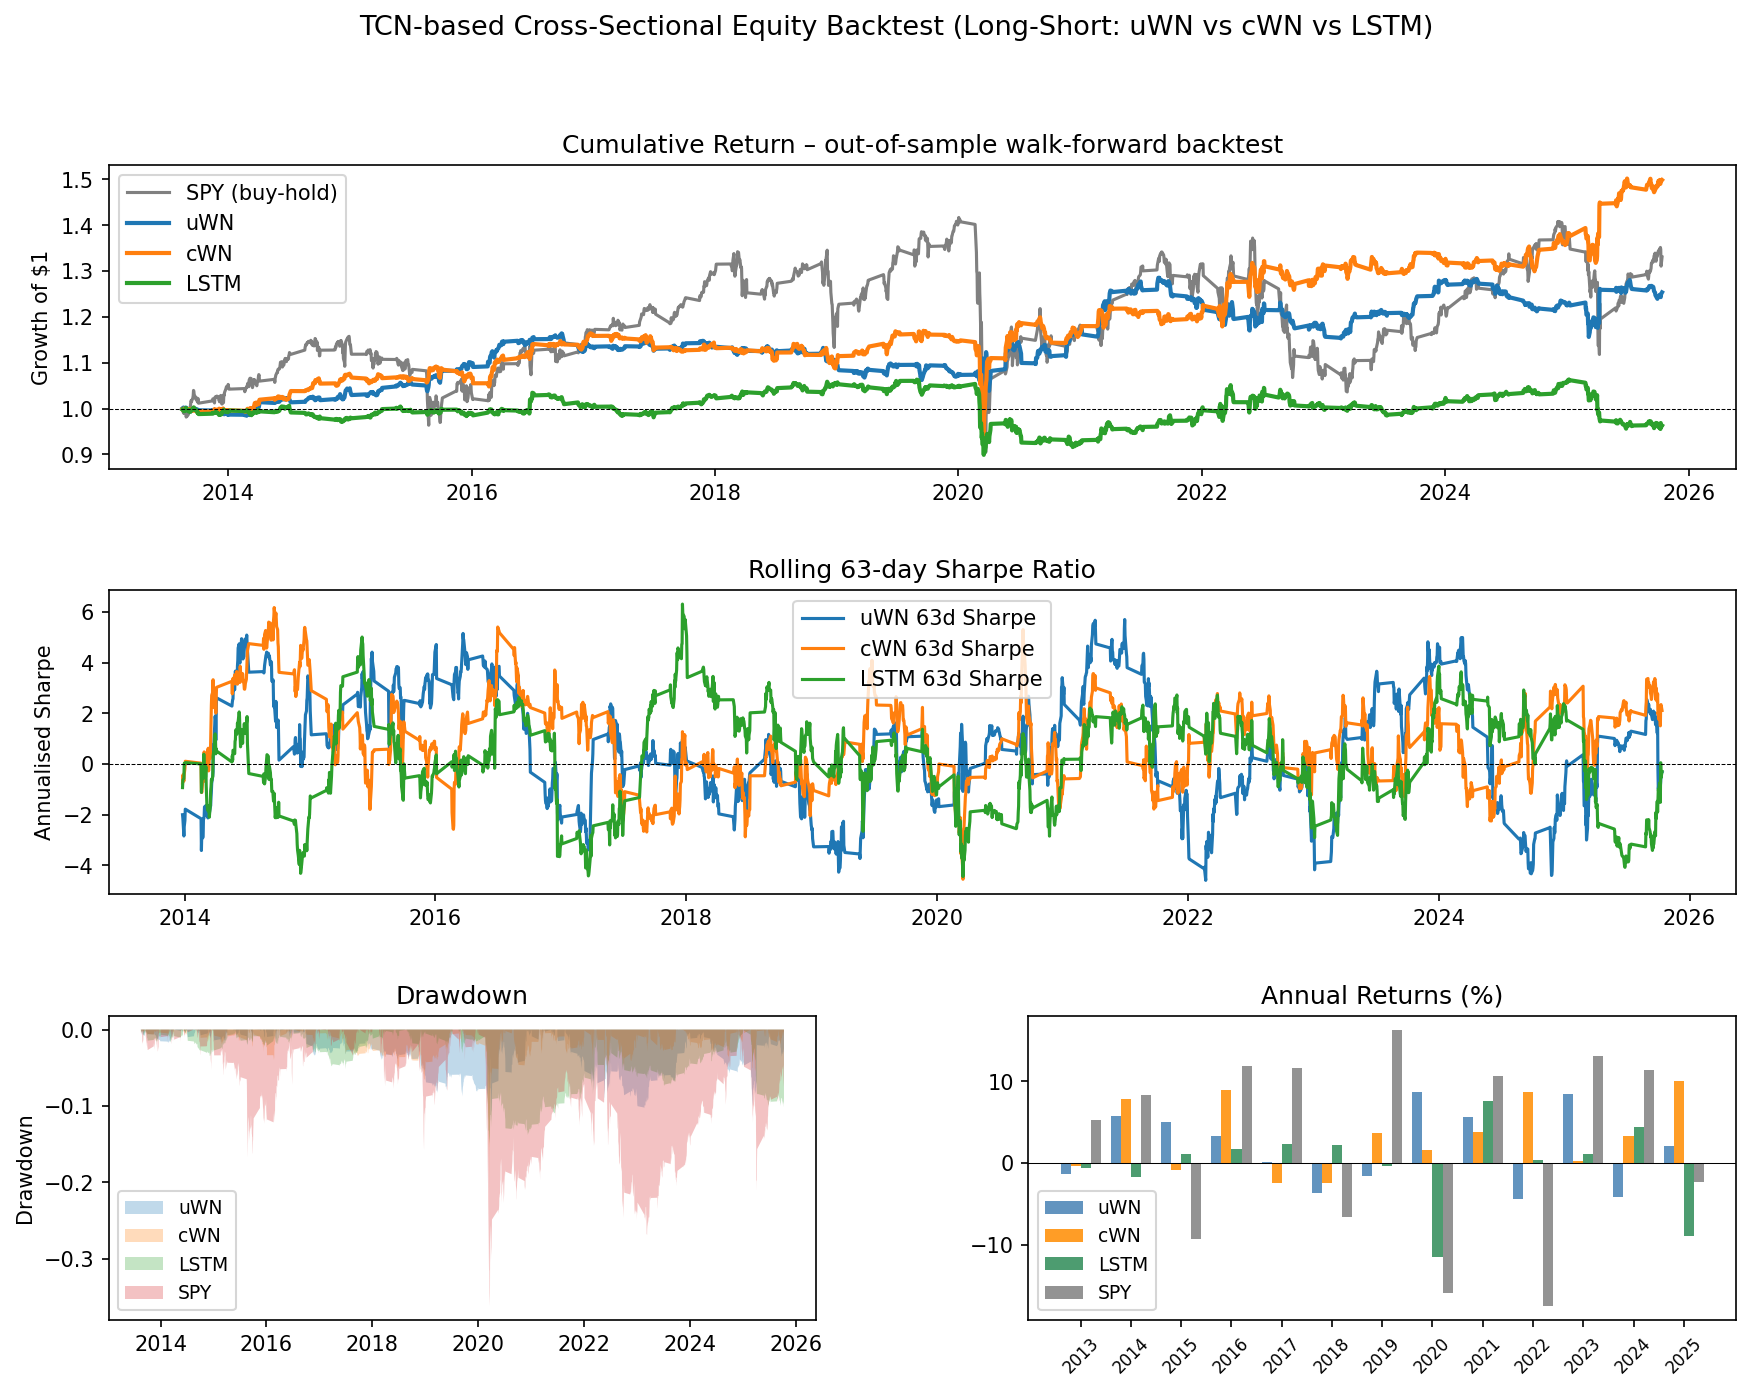

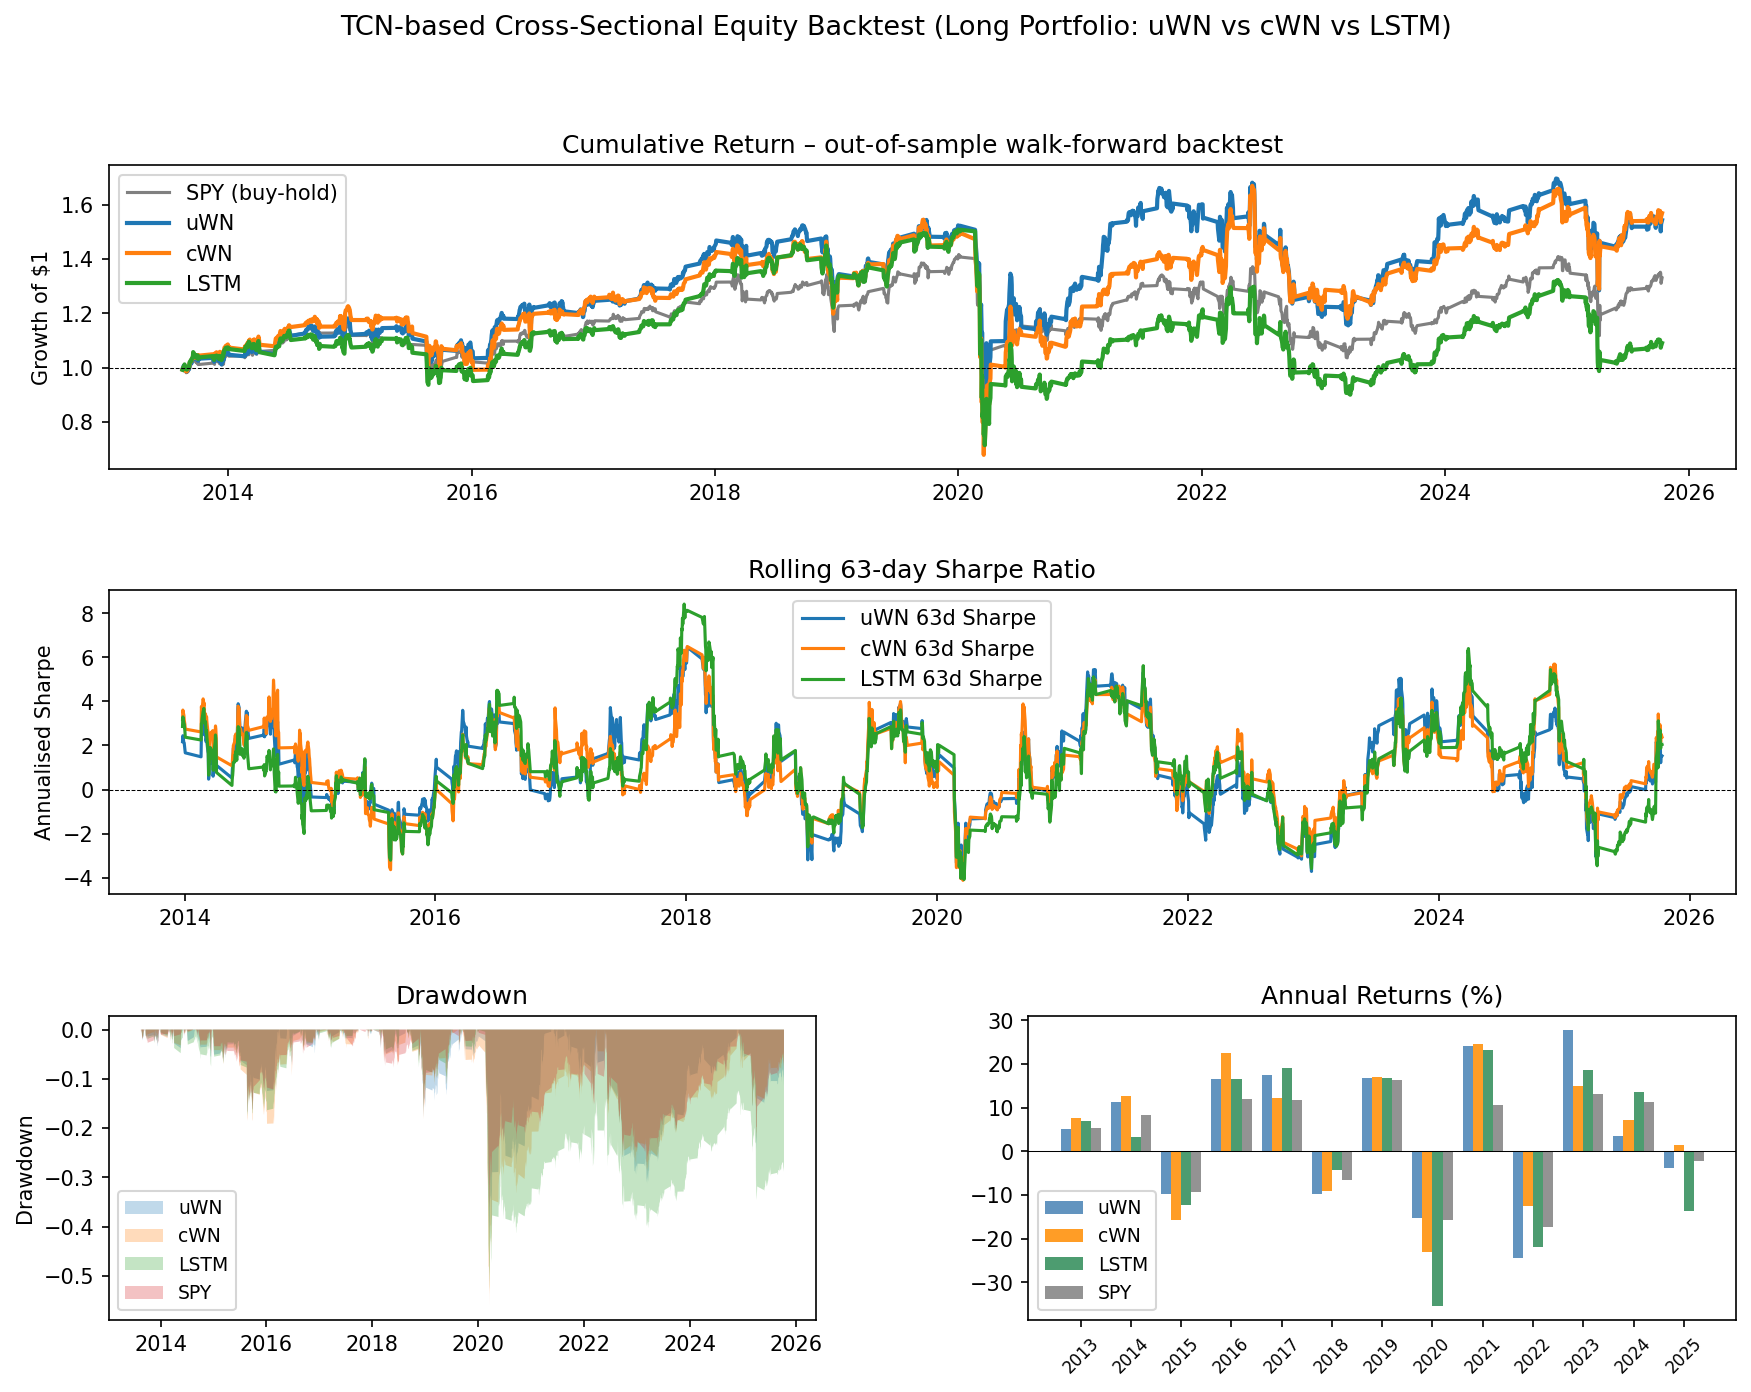

In [10]:
from IPython.display import Image, display

display(Image(filename="results/uWNcWN_LSTM2/backtest_ls_with_lstm.png"))
display(Image(filename="results/uWNcWN_LSTM2/backtest_long_with_lstm.png"))

The backtesting results show clear differences across the three models under both long-short and long-only portfolio settings.

From the long-short cumulative return plot, cWN achieves the strongest overall performance over the full out-of-sample period. Its equity curve grows more steadily after 2020 and ends at the highest level among the three models, reaching close to 1.5 times the initial capital. uWN also generates positive cumulative returns, but its final performance is lower than cWN and its growth becomes flatter after 2022. In contrast, the LSTM strategy remains close to or below the initial capital for most of the sample period, suggesting weaker predictive power in this cross-sectional setting.

The rolling 63-day Sharpe ratio further supports this observation. Both uWN and cWN experience periods of positive and negative risk-adjusted performance, but cWN shows stronger positive Sharpe episodes, especially near the end of the sample. The drawdown plot indicates that all strategies experience losses during stressed periods, particularly around 2020, but the model-based long-short strategies generally have smaller drawdowns than SPY. The annual return chart also shows that cWN produces more consistently positive yearly returns than uWN and LSTM in several years.

The long-only portfolio results provide an additional perspective. In the cumulative return plot, all three models are more closely related to the market trend because the portfolios only take long positions. Before 2020, uWN and cWN both achieve strong growth, with uWN slightly leading in some periods. However, after the market disruption around 2020, cWN recovers more effectively and remains competitive through the later sample period. LSTM also improves under the long-only setting compared with its long-short result, but it still does not consistently outperform uWN or cWN. The rolling Sharpe ratios of the long-only strategies move closely together, showing that their risk-adjusted performance is more affected by common market conditions. The drawdown plot also shows larger downside exposure than the long-short case, especially during market stress, which is expected because the long-only portfolios cannot hedge by taking short positions.

The summary table provides numerical support for these graphical results. For the long-short portfolios, cWN achieves the highest cumulative return of 49.9%, the highest annual return of 6.3%, and the highest Sharpe ratio of 0.726. uWN also performs positively, with a cumulative return of 25.4% and a Sharpe ratio of 0.476. By comparison, LSTM has a negative cumulative return of -3.7% and a slightly negative Sharpe ratio of -0.085, indicating that it fails to generate stable out-of-sample alpha in the long-short setting.

For the long-only portfolios, all three models generate positive cumulative returns. cWN again achieves the highest cumulative return at 56.9%, slightly outperforming uWN at 54.4%. However, the long-only strategies also have much higher annualized volatility and larger maximum drawdowns than their long-short versions. This suggests that the long-only portfolios benefit from market exposure but are also more vulnerable to broad market downturns. Overall, the results suggest that the conditional WaveNet model benefits from incorporating market condition information and provides the best overall out-of-sample performance among the tested models, especially in the long-short portfolio setting.